# 03 Baseline Logistic Regression

Notebook นี้ train Logistic Regression ด้วยข้อมูลหลัง basic preprocessing โดยไม่สร้าง feature engineering เพิ่ม


In [1]:
import sys
import os
os.environ["PYTHONIOENCODING"] = "utf-8"
try:
    sys.stdout.reconfigure(encoding="utf-8")
except Exception:
    pass

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)


## 1. Load Data

อ่านไฟล์ `merged_v1.csv` และตรวจ shape ของ dataframe


In [2]:
DATA_PATH = Path("data/t2_transformed/merged_v1.csv")
df = pd.read_csv(DATA_PATH)
df.shape


(91411, 145)

## 2. Basic Cleaning

ลบ identifier ที่ไม่ใช้เป็น feature, เก็บเฉพาะ row ที่ target ไม่ขัดกัน, ลบ `RedWin`, และใช้ `BlueWin` เป็น target


In [3]:
drop_id_cols = ["MatchFk", "Patch"]
df = df.drop(columns=[c for c in drop_id_cols if c in df.columns], errors="ignore")

df = df[df["BlueWin"] != df["RedWin"]].reset_index(drop=True)
df = df.drop(columns=["RedWin"], errors="ignore")
df["BlueWin"] = df["BlueWin"].astype(int)

target_balance = (
    df["BlueWin"]
    .value_counts()
    .rename_axis("BlueWin")
    .reset_index(name="count")
)
target_balance["ratio"] = target_balance["count"] / target_balance["count"].sum()
display(target_balance)

if "QueueType" in df.columns:
    queue_summary = (
        df["QueueType"]
        .value_counts()
        .rename_axis("QueueType")
        .reset_index(name="count")
    )
    queue_summary["ratio"] = queue_summary["count"] / queue_summary["count"].sum()
    display(queue_summary)

df.shape


,BlueWin,count,ratio
0,1,45702,0.500055
1,0,45692,0.499945


,QueueType,count,ratio
0,CLASSIC,81028,0.886579
1,SWIFTPLAY,6515,0.071285
2,CHERRY,1838,0.020111
3,ARAM,1375,0.015045
4,URF,638,0.006981


(91394, 142)

## 3. Minimal Preprocessing

แปลง `Lane = NONE` เป็น `JUNGLE`, one-hot encode categorical text columns, fill missing values และเตรียม feature matrix สำหรับ Logistic Regression


In [4]:
lane_cols = [f"Lane_P{p}" for p in range(1, 11)]
for c in lane_cols:
    if c in df.columns:
        df[c] = df[c].replace("NONE", "JUNGLE")

target = "BlueWin"
feature_cols = [c for c in df.columns if c != target]

X_raw = df[feature_cols].copy()
y = df[target].copy()

categorical_cols = X_raw.select_dtypes(include=["object", "category"]).columns.tolist()
X_encoded = pd.get_dummies(X_raw, columns=categorical_cols, dummy_na=False)

X_encoded = X_encoded.replace([np.inf, -np.inf], np.nan)
X_encoded = X_encoded.fillna(X_encoded.median(numeric_only=True))

baseline_feature_summary = pd.DataFrame([
    {"item": "Rows", "value": X_encoded.shape[0]},
    {"item": "Raw feature count before encoding", "value": len(feature_cols)},
    {"item": "Categorical columns encoded", "value": len(categorical_cols)},
    {"item": "Feature count after encoding", "value": X_encoded.shape[1]},
    {"item": "Model", "value": "LogisticRegression"},
    {"item": "Feature engineering", "value": "None"},
])

display(baseline_feature_summary)
display(pd.DataFrame({"categorical_column": categorical_cols}))


,item,value
0,Rows,91394
1,Raw feature count before encoding,141
2,Categorical columns encoded,11
3,Feature count after encoding,185
4,Model,LogisticRegression
5,Feature engineering,None


,categorical_column
0,Lane_P1
1,Lane_P10
2,Lane_P2
3,Lane_P3
4,Lane_P4
5,Lane_P5
6,Lane_P6
7,Lane_P7
8,Lane_P8
9,Lane_P9


## 4. Train / Validation / Test Split

แบ่งข้อมูลเป็น train, validation และ test แบบ stratified แล้ว scale feature ด้วย `StandardScaler`


In [5]:
RANDOM_STATE = 1337
VAL_SIZE = 0.15
TEST_SIZE = 0.15

temp_size = VAL_SIZE + TEST_SIZE
X_train, X_temp, y_train, y_temp = train_test_split(
    X_encoded,
    y,
    test_size=temp_size,
    random_state=RANDOM_STATE,
    stratify=y,
)

relative_test_size = TEST_SIZE / temp_size
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=relative_test_size,
    random_state=RANDOM_STATE,
    stratify=y_temp,
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)

split_summary = pd.DataFrame([
    {"split": "train", "rows": len(y_train), "blue_win_ratio": y_train.mean()},
    {"split": "validation", "rows": len(y_val), "blue_win_ratio": y_val.mean()},
    {"split": "test", "rows": len(y_test), "blue_win_ratio": y_test.mean()},
])

display(split_summary)


,split,rows,blue_win_ratio
0,train,63975,0.500055
1,validation,13709,0.500036
2,test,13710,0.500073


## 5. Train Logistic Regression

train Logistic Regression ด้วย fixed parameters และคำนวณ Accuracy, AUC และ F1 บน validation/test set


In [6]:
baseline_model = LogisticRegression(
    C=1.0,
    solver="lbfgs",
    penalty="l2",
    max_iter=500,
    random_state=42,
)

baseline_model.fit(X_train_sc, y_train)

val_pred = baseline_model.predict(X_val_sc)
val_prob = baseline_model.predict_proba(X_val_sc)[:, 1]

test_pred = baseline_model.predict(X_test_sc)
test_prob = baseline_model.predict_proba(X_test_sc)[:, 1]

baseline_metrics = pd.DataFrame([
    {
        "Feature_Set": "Raw encoded features / no feature engineering",
        "Model": "LogisticRegression",
        "Val_Accuracy": accuracy_score(y_val, val_pred),
        "Val_AUC": roc_auc_score(y_val, val_prob),
        "Val_F1": f1_score(y_val, val_pred),
        "Test_Accuracy": accuracy_score(y_test, test_pred),
        "Test_AUC": roc_auc_score(y_test, test_prob),
        "Test_F1": f1_score(y_test, test_pred),
        "Feature_Count": X_encoded.shape[1],
    }
])

display(baseline_metrics)
print(classification_report(y_test, test_pred, target_names=["Red Win", "Blue Win"]))


,Feature_Set,Model,Val_Accuracy,Val_AUC,Val_F1,Test_Accuracy,Test_AUC,Test_F1,Feature_Count
0,Raw encoded features / no feature engineering,LogisticRegression,0.698811,0.775603,0.695838,0.705252,0.782813,0.702758,185


              precision    recall  f1-score   support

     Red Win       0.70      0.71      0.71      6854
    Blue Win       0.71      0.70      0.70      6856

    accuracy                           0.71     13710
   macro avg       0.71      0.71      0.71     13710
weighted avg       0.71      0.71      0.71     13710



## 6. Baseline Visualization

สร้าง ROC curve และ confusion matrix ของ baseline model


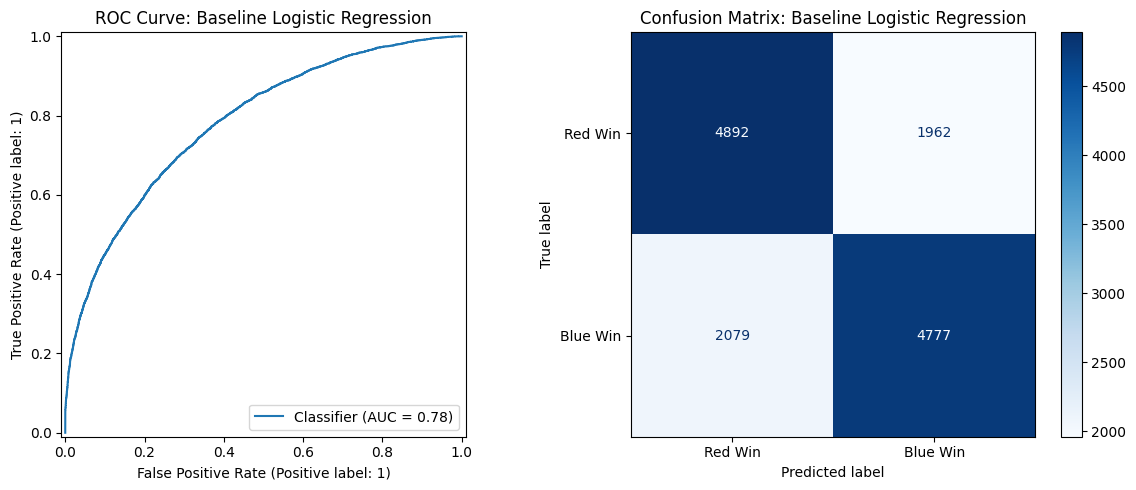

In [7]:
OUTPUT_DIR = Path("outputs/baseline")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

baseline_metrics.to_csv(OUTPUT_DIR / "baseline_metrics.csv", index=False)
baseline_feature_summary.to_csv(OUTPUT_DIR / "baseline_feature_summary.csv", index=False)
split_summary.to_csv(OUTPUT_DIR / "baseline_split_summary.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(y_test, test_prob, ax=axes[0])
axes[0].set_title("ROC Curve: Baseline Logistic Regression")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_pred,
    display_labels=["Red Win", "Blue Win"],
    cmap="Blues",
    ax=axes[1],
)
axes[1].set_title("Confusion Matrix: Baseline Logistic Regression")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "baseline_model_eval.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Logistic Regression Coefficients

คำนวณ absolute coefficient ของ Logistic Regression เพื่อดู feature ที่มีค่าน้ำหนักสูงสุดใน baseline model


,feature,coefficient,importance,direction,importance_rank
0,TotalGold_P8,-0.499344,0.499344,Red-favored,1
1,TotalGold_P1,0.458955,0.458955,Blue-favored,2
2,TotalGold_P4,0.407564,0.407564,Blue-favored,3
3,TotalGold_P6,-0.351357,0.351357,Red-favored,4
4,TotalGold_P3,0.339859,0.339859,Blue-favored,5
5,TotalGold_P9,-0.314973,0.314973,Red-favored,6
6,MinionsKilled_P7,-0.241514,0.241514,Red-favored,7
7,TotalGold_P7,-0.225906,0.225906,Red-favored,8
8,TotalGold_P5,0.221202,0.221202,Blue-favored,9
9,TotalGold_P10,-0.220584,0.220584,Red-favored,10


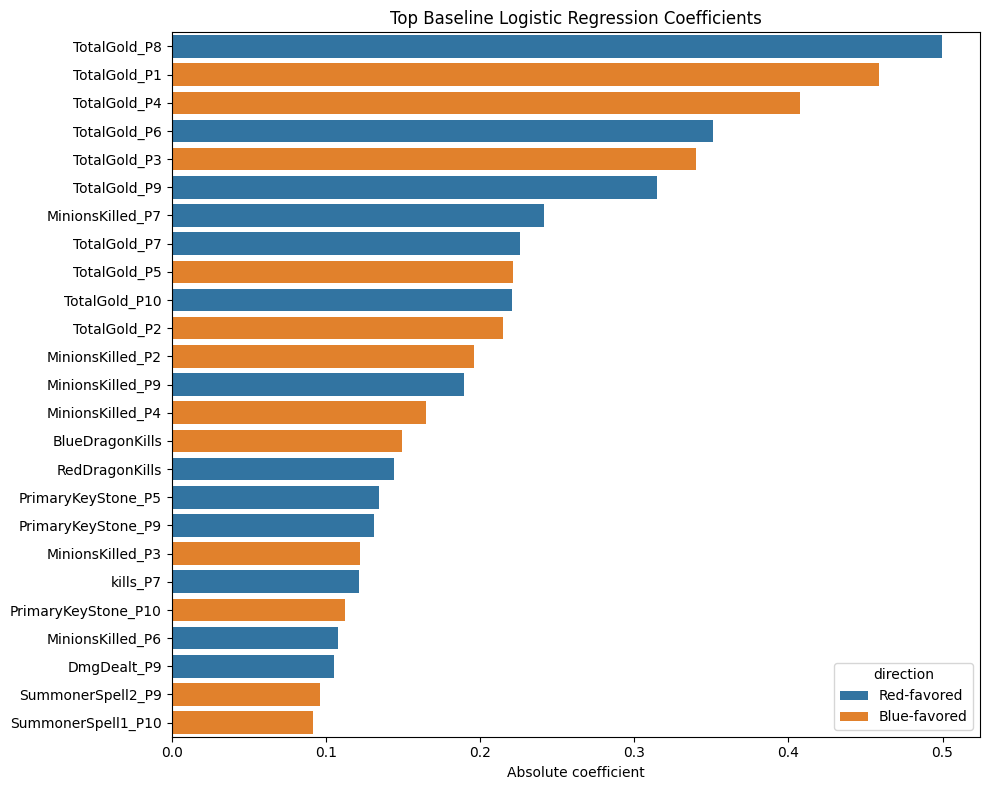

In [8]:
coef_df = pd.DataFrame({
    "feature": X_encoded.columns,
    "coefficient": baseline_model.coef_[0],
})
coef_df["importance"] = coef_df["coefficient"].abs()
coef_df["direction"] = np.where(coef_df["coefficient"] >= 0, "Blue-favored", "Red-favored")
coef_df = coef_df.sort_values("importance", ascending=False).reset_index(drop=True)
coef_df["importance_rank"] = np.arange(1, len(coef_df) + 1)

display(coef_df.head(25))
coef_df.to_csv(OUTPUT_DIR / "baseline_logistic_coefficients.csv", index=False)

top_coef = coef_df.head(25)

plt.figure(figsize=(10, 8))
sns.barplot(data=top_coef, x="importance", y="feature", hue="direction", dodge=False)
plt.title("Top Baseline Logistic Regression Coefficients")
plt.xlabel("Absolute coefficient")
plt.ylabel("")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "baseline_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Output Files

บันทึก metrics, split summary, coefficient table, plots, conclusion text และ serialized baseline model ลง `outputs/baseline`


In [9]:
numeric_conclusion = (
    f"Baseline Logistic Regression without feature engineering: "
    f"Test AUC={baseline_metrics.loc[0, 'Test_AUC']:.4f}, "
    f"Accuracy={baseline_metrics.loc[0, 'Test_Accuracy']:.4f}, "
    f"F1={baseline_metrics.loc[0, 'Test_F1']:.4f}, "
    f"Feature Count={int(baseline_metrics.loc[0, 'Feature_Count'])}."
)

print(numeric_conclusion)
(OUTPUT_DIR / "baseline_conclusion.txt").write_text(numeric_conclusion, encoding="utf-8")
joblib.dump(
    {"model": baseline_model, "scaler": scaler, "feature_columns": X_encoded.columns.tolist()},
    OUTPUT_DIR / "baseline_logistic_model.joblib",
)

print(f"Outputs saved to: {OUTPUT_DIR.resolve()}")


Baseline Logistic Regression without feature engineering: Test AUC=0.7828, Accuracy=0.7053, F1=0.7028, Feature Count=185.
Outputs saved to: C:\Users\USER\Desktop\Predicting-Match-Result-LOL-DataModels\outputs\baseline
